In [1]:
from google.colab import files

uploaded = files.upload()

In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("hotel_bookings.csv")

# Display the first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Basic information about the dataset

print("Shape of the dataset:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape of the dataset: (119390, 32)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data Types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights 

In [4]:
## Data Quality Assessment
# Missing Values Analysis

missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
company,112593
agent,16340
country,488
children,4


In [5]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 31994


In [6]:
# Statistical Summary

df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [7]:
# Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
# ==================================================
# DATA CLEANING
# ==================================================
df.drop(columns=['company'], inplace=True)

In [9]:
# Fill missing values

df['agent'].fillna(0, inplace=True)

df['country'].fillna(df['country'].mode()[0], inplace=True)

df['children'].fillna(df['children'].median(), inplace=True)

/tmp/ipykernel_1669/953500903.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['agent'].fillna(0, inplace=True)
/tmp/ipykernel_1669/953500903.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.metho

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
print("Shape after cleaning:", df.shape)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\nDuplicate Records After Cleaning:")
print(df.duplicated().sum())

Shape after cleaning: (87370, 31)

Missing Values After Cleaning:
hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
arrival_date_day_of_month         0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
agent                             0
days_in_waiting_list              0
customer_type                     

In [12]:
# ==================================================
# AUTOMATED REPORTING
# ==================================================
print("=" * 50)
print("DATA CLEANING REPORT")
print("=" * 50)

print(f"Original Rows : 119390")
print(f"Cleaned Rows  : {len(df)}")

print(f"\nTotal Columns : {df.shape[1]}")

print("\nMissing Values Remaining:")
print(df.isnull().sum().sum())

print("\nDuplicate Records Remaining:")
print(df.duplicated().sum())

DATA CLEANING REPORT
Original Rows : 119390
Cleaned Rows  : 87370

Total Columns : 31

Missing Values Remaining:
0

Duplicate Records Remaining:
0


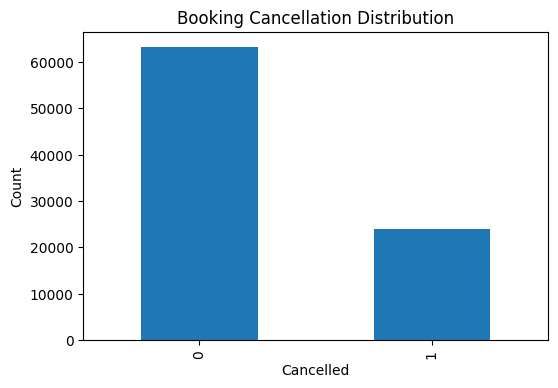

In [13]:
# ==================================================
# DATA VISUALIZATION
# ==================================================
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df['is_canceled'].value_counts().plot(kind='bar')

plt.title("Booking Cancellation Distribution")
plt.xlabel("Cancelled")
plt.ylabel("Count")

plt.show()

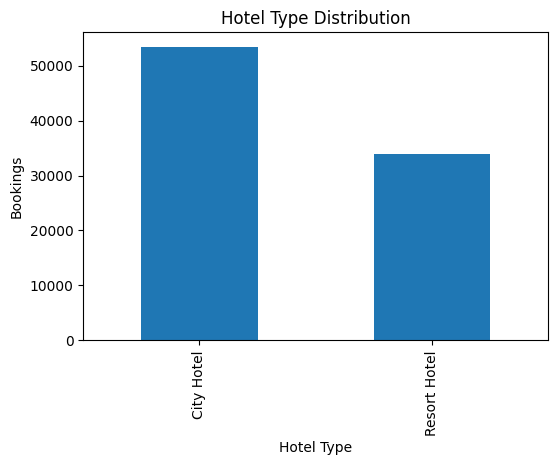

In [14]:
plt.figure(figsize=(6,4))

df['hotel'].value_counts().plot(kind='bar')

plt.title("Hotel Type Distribution")
plt.xlabel("Hotel Type")
plt.ylabel("Bookings")

plt.show()

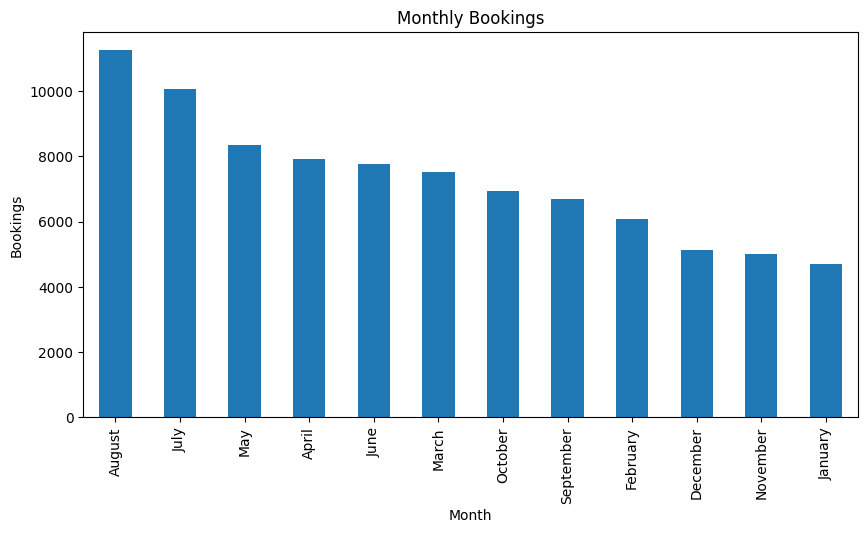

In [15]:
plt.figure(figsize=(10,5))

df['arrival_date_month'].value_counts().plot(kind='bar')

plt.title("Monthly Bookings")
plt.xlabel("Month")
plt.ylabel("Bookings")

plt.show()

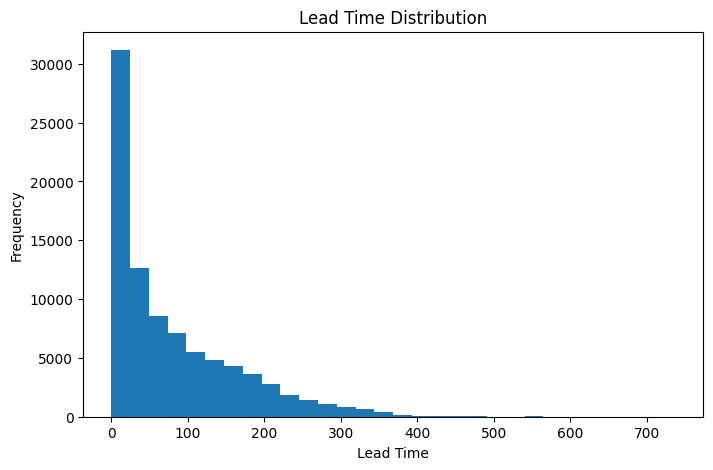

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df['lead_time'], bins=30)

plt.title("Lead Time Distribution")
plt.xlabel("Lead Time")
plt.ylabel("Frequency")

plt.show()

In [17]:
df.to_csv("cleaned_hotel_bookings.csv", index=False)

print("✅ Cleaned dataset exported successfully.")

✅ Cleaned dataset exported successfully.


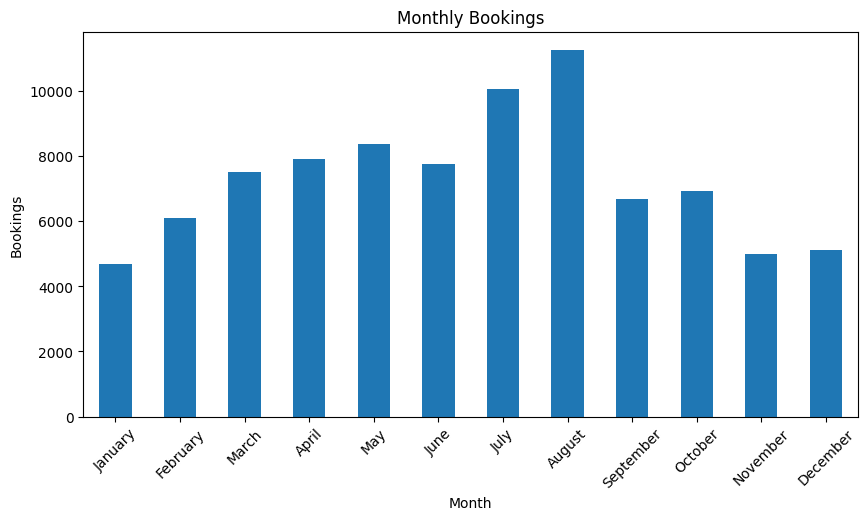

In [18]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

monthly = df['arrival_date_month'].value_counts().reindex(month_order)

plt.figure(figsize=(10,5))
monthly.plot(kind='bar')

plt.title("Monthly Bookings")
plt.xlabel("Month")
plt.ylabel("Bookings")
plt.xticks(rotation=45)

plt.show()

In [19]:
print("Original Shape: (119390, 32)")
print("Cleaned Shape :", df.shape)

Original Shape: (119390, 32)
Cleaned Shape : (87370, 31)


In [20]:
plt.savefig("monthly_bookings.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [21]:
print("="*50)
print("PROJECT SUMMARY")
print("="*50)

print("Original Dataset Shape :", (119390, 32))
print("Cleaned Dataset Shape  :", df.shape)

print("\nCleaning Operations Performed:")
print("✔ Removed 'company' column")
print("✔ Filled missing values in 'agent'")
print("✔ Filled missing values in 'country'")
print("✔ Filled missing values in 'children'")
print("✔ Removed duplicate records")
print("✔ Generated summary statistics")
print("✔ Created data visualizations")
print("✔ Exported cleaned dataset")

print("\nProject Completed Successfully!")

PROJECT SUMMARY
Original Dataset Shape : (119390, 32)
Cleaned Dataset Shape  : (87370, 31)

Cleaning Operations Performed:
✔ Removed 'company' column
✔ Filled missing values in 'agent'
✔ Filled missing values in 'country'
✔ Filled missing values in 'children'
✔ Removed duplicate records
✔ Generated summary statistics
✔ Created data visualizations
✔ Exported cleaned dataset

Project Completed Successfully!
